### Imports e iniciando cessão com o S3

In [1]:
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *

load_dotenv()

True

In [2]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")

In [3]:
def listar_apenas_pastas(s3_client, bucket: str):
    paginator = s3_client.get_paginator('list_objects_v2')
    todas_pastas = set()

    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            partes = obj['Key'].split('/')
            if len(partes) > 1:
                # Adiciona o caminho da pasta
                pasta = "/".join(partes[:-1])
                todas_pastas.add(pasta)

    print(f"📁 Pastas encontradas em s3://{bucket}/:\n")
    for pasta in sorted(todas_pastas):
        print(f"- {pasta}")

# Executar:
listar_apenas_pastas(s3, BUCKET)


📁 Pastas encontradas em s3://postech-challenge-datascience-003/:

- bronze/ano=2023/dados
- bronze/ano=2023/dicionario
- bronze/ano=2024/dados
- bronze/ano=2024/dicionario
- bronze/ano=2025/dados
- bronze/ano=2025/dicionario
- gold/ano=dimensao/dados
- gold/ano=historico/dados
- gold/dados_externos
- gold/fato/ano=2026/dados
- gold/modelo
- models
- silver/ano=2023/dados
- silver/ano=2024/dados
- silver/ano=2025/dados
- silver/metadata/ano=2026/dados


In [4]:
prefixo = "gold/dados_externos"

response = s3.list_objects_v2(Bucket=BUCKET,Prefix=prefixo)

if "Contents" in response:
    print(f"Arquivos encontrados em s3://{BUCKET}/{prefixo}:\n")
    for obj in response["Contents"]:
        nome_arquivo = obj['Key'].split('/')[-1]
        nome_arquivo = nome_arquivo.replace(".parquet","")
        tamanho_kb = obj["Size"] / 1024 
        print(f"- {nome_arquivo} ({tamanho_kb:.2f} KB)")
else:
    print(f"Nenhum arquivo encontrado em s3://{BUCKET}/{prefixo}")



Arquivos encontrados em s3://postech-challenge-datascience-003/gold/dados_externos:

-  (0.00 KB)
- analise_municipio (705.43 KB)
- analise_uf (20.16 KB)
- dim_contexto_socioeconomico_uf (7.79 KB)
- fact_escola (3827.88 KB)
- fact_municipio (100.49 KB)
- fact_uf_ano (25.09 KB)
- ranking_prioridade (966.98 KB)


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [4]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_alunos            = carregar_parquet_s3(s3, BUCKET, "TS_ALUNO", ano="historico")
df_municipios        = carregar_parquet_s3(s3, BUCKET, "TS_MUNICIPIO", ano="historico")
df_estados           = carregar_parquet_s3(s3, BUCKET, "TS_ESTADO", ano="historico")


df_meta              = carregar_parquet_s3(s3, BUCKET, "Fato_Alfabetizacao_Meta", subpasta="fato/ano=2026/dados")
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, "FATO_ALFABETIZACAO", subpasta="fato/ano=2026/dados")


df_fact_escola       = carregar_parquet_s3(s3, BUCKET, "fact_escola", subpasta="dados_externos")


Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet


## <font color="green">Enriquecendo a tabela dos Alunos </font>

A analise exploratória e enriquecimento foi feito por todos os integrandes do grupo, em notebooks diferentes

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [6]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [9]:
# 1. Filtramos pelo TOTAL GERAL do Município (ID_TIPO_REDE == 5)
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_muni_total = df_municipios[df_municipios['ID_TIPO_REDE'] == 5][cols_muni].copy()

# 2. Renomeamos para as colunas finais
df_muni_total = df_muni_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Se a coluna já existia com nulos no df_alunos, removemos ela antes para recriar limpa
cols_existentes_remover = [c for c in ['VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'] if c in df_alunos.columns]
if cols_existentes_remover:
    df_alunos = df_alunos.drop(columns=cols_existentes_remover)

# 4. Fazemos o Merge perfeito
df_alunos = df_alunos.merge(
    df_muni_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
    how='left'
)

print("✅ Merge concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO:", df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().mean():.2%}")


✅ Merge concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO: 3929
Percentual de nulos: 0.06%


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [ ]:
# 1. Selecionamos as colunas e filtramos pelo TOTAL DO ESTADO (ID_TIPO_REDE == 5)
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF' 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_estados_total = df_estados[df_estados['ID_TIPO_REDE'] == 5][cols_uf].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_total = df_estados_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Removemos as colunas antigas com nulos do df_alunos antes de recriar
cols_uf_remover = [c for c in ['VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'] if c in df_alunos.columns]
if cols_uf_remover:
    df_alunos = df_alunos.drop(columns=cols_uf_remover)

# 4. Fazemos o Merge perfeito com o Total do Estado
df_alunos = df_alunos.merge(
    df_estados_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
    on=['NU_ANO_AVALIACAO', 'CO_UF'],
    how='left'
)

print("✅ Merge de Estado concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_UF:", df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().mean():.2%}")


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [ ]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [ ]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 40


In [ ]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

## MODELOS

### <font color="green"> Funções </font>

In [29]:
def avaliar(nome, y_true, y_pred, y_proba=None):
    print(f"\n{'='*45}")
    print(f"  {nome}")
    print(f"{'='*45}")
    print(f"  Acurácia : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precisão : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    if y_proba is not None:
        print(f"  AUC-ROC  : {roc_auc_score(y_true, y_proba):.4f}")



def plot_classificacao(model, X_test, y_test, model_name="Modelo"):
    # Previsões de classe (0 ou 1) e de probabilidade (0.0 a 1.0)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # ── 1. Matriz de Confusão ──
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=["Não Alfabetizado", "Alfabetizado"]
    )
    disp.plot(ax=ax[0], cmap="Blues", values_format="d")
    ax[0].set_title(f"Matriz de Confusão ({model_name})", fontsize=12, weight="bold")
    
    # ── 2. Curva ROC ──
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    score_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {score_auc:.4f})")
    ax[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Aleatório (0.50)")
    ax[1].set_xlabel("Taxa de Falsos Positivos")
    ax[1].set_ylabel("Taxa de Verdadeiros Positivos")
    ax[1].set_title(f"Curva ROC ({model_name})", fontsize=12, weight="bold")
    ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

### <font color="green">Feat Engenering</font>

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lightgbm as lgb_lib
import xgboost as xgb_lib
from xgboost import XGBRegressor

from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)



In [ ]:
df_modelo = carregar_parquet_s3(s3_client=s3,bucket=BUCKET,nome_tabela="tabela_modelo",subpasta="modelo")

df_modelo.head(5)

,NU_ANO_AVALIACAO,CO_UF,TP_DEPENDENCIA,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,IN_ALFABETIZADO,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,ID_ESCOLA,CO_MUNICIPIO
0,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
1,2023,11,3.0,1,1,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
2,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
3,2023,11,3.0,1,1,1,2916.0,1524.801152,89.593066,60000001.0,1100205.0
4,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0


Trabalhando as variaveis de REDE  
a utilização do onehot encoder é util para essas variaveis categoricas com poucas variaveis

In [17]:
#  Mapeamento dos códigos 
mapa_dependencia = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
}

df_modelo["REDE"] = df_modelo["TP_DEPENDENCIA"].map(mapa_dependencia)

#Instancia o OneHotEncoder (sparse_output=False já entrega um array normal em vez de matriz esparsa)
cat_encoder = OneHotEncoder(sparse_output=False, dtype=int)
# fit_transform  
rede_1hot = cat_encoder.fit_transform(df_modelo[["REDE"]])

# Transformar as categorias em um dataframe
colunas_nomes = cat_encoder.get_feature_names_out(["REDE"])
df_rede_1hot = pd.DataFrame(rede_1hot, columns=colunas_nomes, index=df_modelo.index)
# agregar as novas tabelas ao dataframe 
df_modelo = pd.concat([df_modelo, df_rede_1hot], axis=1)

print("✅ Colunas criadas pelo OneHotEncoder:")
display(df_modelo[colunas_nomes].head())

✅ Colunas criadas pelo OneHotEncoder:


,REDE_Estadual,REDE_Municipal,REDE_Privada
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


Criando as features para a escola

In [18]:
# Indicadores Individuais e de Test-Taking 
df_modelo["IN_AUSENTE"] = (df_modelo["IN_PRESENCA_LP"] == 0).astype("int8")

# Features da Escola (Porte, Absenteísmo, Engajamento)
if "ID_ESCOLA" in df_modelo.columns:
    df_modelo["porte_escola_alunos"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_PRESENCA_LP"].transform("count")
    )
    df_modelo["taxa_absenteismo_escola"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_AUSENTE"].transform("mean")
    )
    df_modelo["taxa_preenchimento_escola"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_PREENCHIMENTO_LP"].transform("mean")
    )


#Normalizando a frequencia escolar da escola
df_modelo["freq_escolar_norm"] = df_modelo["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] / 100.0


# Features do Município

if "CO_MUNICIPIO" in df_modelo.columns:
    df_modelo["porte_muni_alunos"] = (
        df_modelo.groupby("CO_MUNICIPIO")["IN_PRESENCA_LP"].transform("count")
    )
    df_modelo["taxa_absenteismo_muni"] = (
        df_modelo.groupby("CO_MUNICIPIO")["IN_AUSENTE"].transform("mean")
    )



#Features Socioeconômicas Relativas, utilizarei o Z-Score para normalizar os dados, dentro da média e o desvio padrão do ano especifico   

# Instancia o scaler
scaler = StandardScaler()

# fit_transform na coluna de renda 

df_modelo["RENDA_ZSCORE_ANO"] = (
    df_modelo.groupby("NU_ANO_AVALIACAO")["RENDA_PERCAPITA_SBENEF_MEDIO"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

print("Média do Z-score:", df_modelo["RENDA_ZSCORE_ANO"].mean().round(4))  # Fica exatamente 0.0
print("Desvio padrão  :", df_modelo["RENDA_ZSCORE_ANO"].std().round(4))   # Fica exatamente 1.0



#Features de região 

mapa_co_uf_regiao = {
    11: "Norte", 12: "Norte", 13: "Norte", 14: "Norte", 15: "Norte", 16: "Norte", 17: "Norte",
    21: "Nordeste", 22: "Nordeste", 23: "Nordeste", 24: "Nordeste", 25: "Nordeste", 26: "Nordeste", 27: "Nordeste", 28: "Nordeste", 29: "Nordeste",
    31: "Sudeste", 32: "Sudeste", 33: "Sudeste", 35: "Sudeste",
    41: "Sul", 42: "Sul", 43: "Sul",
    50: "Centro-Oeste", 51: "Centro-Oeste", 52: "Centro-Oeste", 53: "Centro-Oeste"
}
if "CO_UF" in df_modelo.columns:
    df_modelo["REGIAO"] = df_modelo["CO_UF"].map(mapa_co_uf_regiao)

# One-Hot Encoding da REGIAO
df_regiao_1hot = pd.get_dummies(df_modelo["REGIAO"], prefix="REGIAO", dtype="int8")
df_modelo = pd.concat([df_modelo, df_regiao_1hot], axis=1)


# Normalização Logarítmica nos portes de escola e município
df_modelo["log_porte_escola"] = np.log1p(df_modelo["porte_escola_alunos"])
df_modelo["log_porte_muni"]   = np.log1p(df_modelo["porte_muni_alunos"])

Média do Z-score: -0.0
Desvio padrão  : 1.0


In [19]:
# features que serão selecionadas, ficaremos com as já tratadas e normalizadas 
features = [
    #TARGET
    "IN_ALFABETIZADO" ,
    # Nível Escola
    "taxa_absenteismo_escola",
    "log_porte_escola",
    
    # Nível Município
    "taxa_absenteismo_muni",
    "log_porte_muni",
    
    # Nível Rede (Dummies)
    "REDE_Estadual",
    "REDE_Municipal",
    "REDE_Privada",
    
    # Nível Socioeconômico e Geográfico
    "RENDA_ZSCORE_ANO",
    "freq_escolar_norm",
    
    # Regiões (Dummies)
    "REGIAO_Centro-Oeste",
    "REGIAO_Nordeste",
    "REGIAO_Norte",
    "REGIAO_Sudeste",
    "REGIAO_Sul"
]


### <font color="green"> Treino </font>

In [20]:
df_treino = df_modelo[features].copy()

y = df_treino['IN_ALFABETIZADO']
X = df_treino.drop(columns=['IN_ALFABETIZADO'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% teste
    random_state=42  # reprodutibilidade
)

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Espaço de busca dos melhores hiperparâmetros
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.7, 0.8]
}

# Base da Random Forest CLASSIFIER usando todos os núcleos da CPU
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Busca inteligente em uma amostra de 50 mil linhas para ser rápido
X_sample = X_train.sample(n=min(50000, len(X_train)), random_state=42)
y_sample = y_train.loc[X_sample.index]

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,               # Testa 10 combinações diferentes
    cv=3,
    scoring='roc_auc',       # MÉTRICA DE CLASSIFICAÇÃO (AUC-ROC em vez de R²)
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print(" Buscando os melhores hiperparâmetros da Random Forest (Classificação)...")
random_search.fit(X_sample, y_sample)

print("Melhores Hiperparâmetros encontrados:")
print(random_search.best_params_)
print(f"Melhor AUC-ROC na validação: {random_search.best_score_:.4f}")

# 4. Treina a Random Forest definitiva com os parâmetros campeões na base completa
rf = RandomForestClassifier(
    **random_search.best_params_, 
    n_jobs=-1, 
    random_state=42
)
rf.fit(X_train, y_train)

# 5. Predição de Classes (0 ou 1) e Probabilidades
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(" Random Forest de Classificação treinada com sucesso!")


 Buscando os melhores hiperparâmetros da Random Forest (Classificação)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores Hiperparâmetros encontrados:
{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 20}
Melhor AUC-ROC na validação: 0.6501
 Random Forest de Classificação treinada com sucesso!


In [22]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. Configuração do LightGBM Classifier
lgbm = lgb.LGBMClassifier(
    n_estimators=500,               # Quantidade de árvores
    learning_rate=0.05,             # Taxa de aprendizado
    num_leaves=31,                  # Principal parâmetro do LightGBM (complexidade da árvore)
    max_depth=6,                    # Evita overfitting
    subsample=0.8,                  # 80% das linhas por árvore
    colsample_bytree=0.8,           # 80% das colunas por árvore
    random_state=42,
    n_jobs=-1                       # Usa todos os núcleos da CPU em paralelo ultra-rápido
)

# Treinamento com Early Stopping
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=15, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

# Predições
y_pred_lgbm = lgbm.predict(X_test)
y_pred_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print(" Treino concluido")
print(f"Melhor iteração: {lgbm.best_iteration_}")


c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 2630174, number of negative: 2241956
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1134
[LightGBM] [Info] Number of data points in the train set: 4872130, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.539841 -> initscore=0.159701
[LightGBM] [Info] Start training from score 0.159701
Training until validation scores don't improve for 15 rounds
[50]	valid_0's auc: 0.655621	valid_0's binary_logloss: 0.65186
[100]	valid_0's auc: 0.660116	valid_0's binary_logloss: 0.648089
[150]	valid_0's auc: 0.662762	valid_0's binary_logloss: 0.646503
[200]	valid_0's auc: 0.664332	valid_0's binary_logloss: 0.645551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[250]	valid_0's auc: 0.665524	valid_0's bina

In [23]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

# Configuração do Classificador na GPU
xgb = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    device="cuda",               # Configurar para GPU
    early_stopping_rounds=15,
    eval_metric="auc",           # Monitora a área sob a curva ROC
    random_state=42
)

# 2. Treinamento na GPU
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# 3. Predição de Classes (0 ou 1) e de Probabilidades (0.0 a 1.0)
y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

print(" Treino concluido")
print(f"Melhor iteração (árvore): {xgb.best_iteration}")


[0]	validation_0-auc:0.62968
[50]	validation_0-auc:0.65308
[100]	validation_0-auc:0.65864
[150]	validation_0-auc:0.66137
[200]	validation_0-auc:0.66324
[250]	validation_0-auc:0.66446
[300]	validation_0-auc:0.66560
[350]	validation_0-auc:0.66662
[400]	validation_0-auc:0.66748
[450]	validation_0-auc:0.66826
[499]	validation_0-auc:0.66893


c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\xgboost\core.py:569: UserWarning: [19:50:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


 Treino concluido
Melhor iteração (árvore): 499


### <font color="green">Avaliações </font>

In [24]:
# Baseline (Chuta a classe mais frequente do treino para todos) 
classe_majoritaria = y_train.mode()[0]
y_pred_baseline = [classe_majoritaria] * len(y_test)
avaliar("Baseline (Maioria)", y_test, y_pred_baseline)

# Random Forest 
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
avaliar("Random Forest", y_test, y_pred_rf, y_proba_rf)

# XGBoost 
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
avaliar("XGBoost ", y_test, y_pred_xgb, y_proba_xgb)

# LightGBM 
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
avaliar("LightGBM", y_test, y_pred_lgbm, y_proba_lgbm)



  Baseline (Maioria)
  Acurácia : 0.5394
  Precisão : 0.5394
  Recall   : 1.0000
  F1-Score : 0.7008

  Random Forest
  Acurácia : 0.6458
  Precisão : 0.6571
  Recall   : 0.7181
  F1-Score : 0.6863
  AUC-ROC  : 0.7017

  XGBoost 
  Acurácia : 0.6221
  Precisão : 0.6329
  Recall   : 0.7132
  F1-Score : 0.6707
  AUC-ROC  : 0.6689

  LightGBM
  Acurácia : 0.6224
  Precisão : 0.6332
  Recall   : 0.7130
  F1-Score : 0.6707
  AUC-ROC  : 0.6694


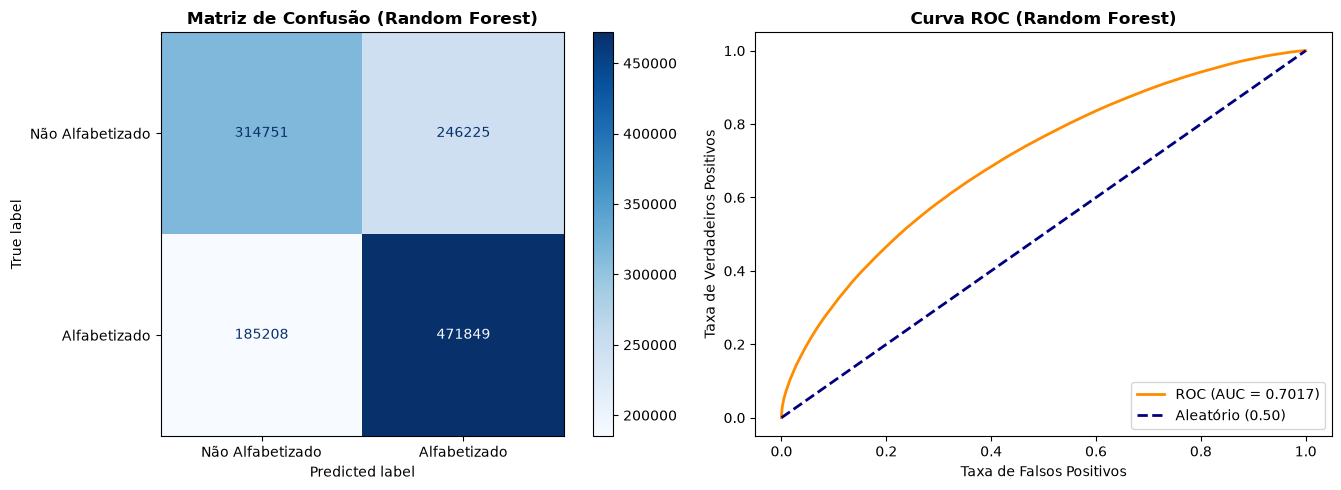

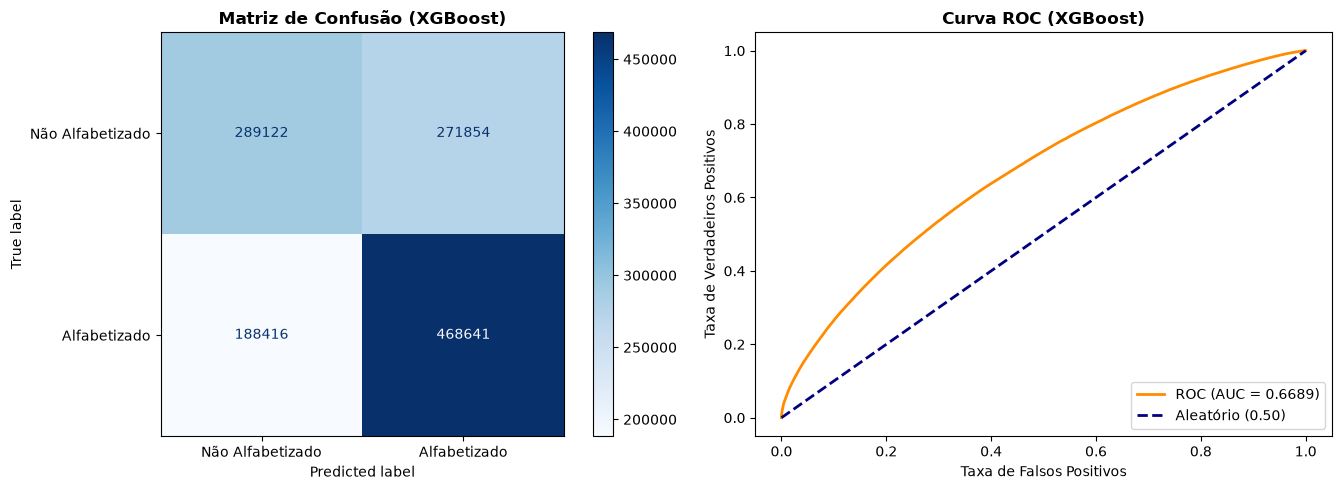

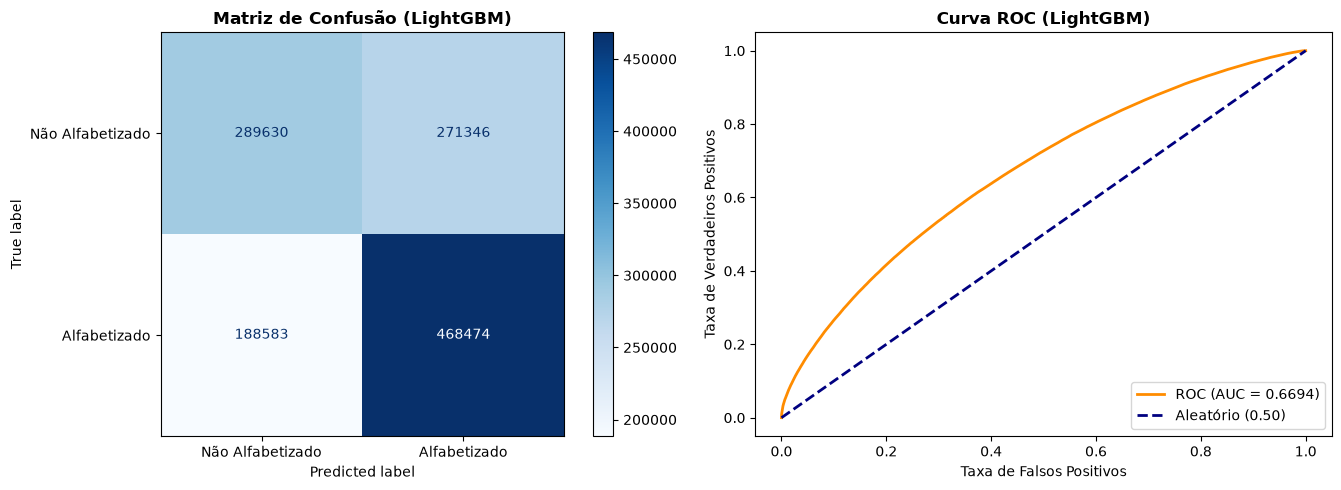

In [25]:
plot_classificacao(rf, X_test, y_test, model_name="Random Forest")

plot_classificacao(xgb, X_test, y_test, model_name="XGBoost")

plot_classificacao(lgbm, X_test, y_test, model_name="LightGBM")

### <font color="green"> Salvando Modelo </font>

In [ ]:
import joblib
import os

# Garante que a pasta models existe
os.makedirs("models", exist_ok=True)

# Salva o modelo treinado
caminho_local = "models/melhor_modelo_random_forest.joblib"
joblib.dump(rf, caminho_local)

tamanho_mb = os.path.getsize(caminho_local) / (1024 * 1024)
print(f"Modelo Random Forest salvo com sucesso em: {caminho_local} ({tamanho_mb:.2f} MB)")

#SALVAR NO S3 
caminho_s3 = "models/melhor_modelo_random_forest.joblib"

# Faz o upload do arquivo salvo para o bucket
s3.upload_file(caminho_local, BUCKET, caminho_s3)
print(f" Modelo enviado com sucesso para s3://{BUCKET}/{caminho_s3}!")

Modelo Random Forest salvo com sucesso em: models/melhor_modelo_random_forest.joblib (1059.38 MB)
 Modelo enviado com sucesso para s3://postech-challenge-datascience-003/models/melhor_modelo_random_forest.joblib!


### <font color="green"> Avaliação </font>

In [ ]:
# import joblib
# # Carrega o modelo treinado instantaneamente (sem precisar treinar de novo)
# modelo_carregado = joblib.load("models/melhor_modelo_random_forest.joblib")

# # Faz previsões com ele:
# novas_previsoes = modelo_carregado.predict(X_test)
# print("Previsões geradas com sucesso!")

In [ ]:
#  Pega a base atual de teste
X_futuro = X_test.copy()

#  Simula o avanço do tempo (ex: no futuro, os municípios reduzem o absenteísmo em 20%)
X_futuro["taxa_absenteismo_escola"] = X_futuro["taxa_absenteismo_escola"] * 0.80
X_futuro["taxa_absenteismo_muni"]   = X_futuro["taxa_absenteismo_muni"] * 0.80

#  O modelo prevê a nova taxa individual dos alunos nesse cenário futuro
novas_probabilidades = rf.predict_proba(X_futuro)[:, 1]
nova_taxa_media = novas_probabilidades.mean() * 100

taxa_atual = y_test.mean() * 100
print(f"  Taxa de Alfabetização Atual               : {taxa_atual:.1f}%")
print(f"  Taxa Prevista com Queda no Absenteísmo    : {nova_taxa_media:.1f}%")
print(f"  Ganho Estimado                            : +{(nova_taxa_media - taxa_atual):.1f} pontos percentuais")


  Taxa de Alfabetização Atual               : 53.9%
  Taxa Prevista com Queda no Absenteísmo    : 58.1%
  Ganho Estimado                            : +4.2 pontos percentuais


In [ ]:
# Pega os dados consolidados do Brasil 

brasil = resultado_metas[resultado_metas["SIGLA_UF"].isna()].iloc[0]

anos_historico  = [2019, 2021, 2023]
taxas_historico = [float(brasil["SAEB_2019"]), float(brasil["SAEB_2021"]), float(brasil["PC_ALUNO_ALFABETIZADO"])]

print("Anos Históricos:", anos_historico)
print("Taxas Históricas (%):", taxas_historico)


Anos Históricos: [2019, 2021, 2023]
Taxas Históricas (%): [54.7, 35.77, 55.89811007513037]


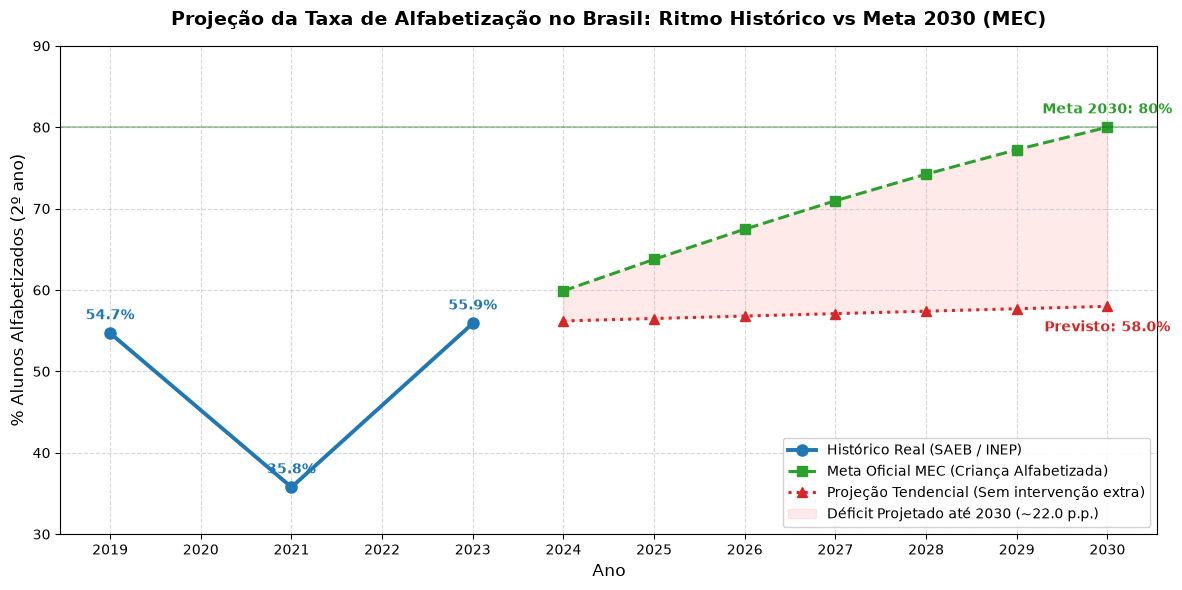

Conclusão da Projeção:
Taxa observada em 2023: 55.90%
Projeção inercial para 2030: 57.99%
Meta oficial do MEC para 2030: 80.00%
Gap a ser superado: 22.01 pontos percentuais


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Extração dos Dados Oficiais (Brasil) 
linha_brasil = resultado_metas[resultado_metas["NOME_UF"] == "Brasil"].iloc[0]

# Histórico Real Observado no SAEB (2019 a 2023)
anos_hist = np.array([2019, 2021, 2023]).reshape(-1, 1)
taxas_hist = np.array([
    linha_brasil["SAEB_2019"],
    linha_brasil["SAEB_2021"],
    linha_brasil["PC_ALUNO_ALFABETIZADO"]
])

# Metas Oficiais do MEC (2024 a 2030)
anos_futuros = np.array([2024, 2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
metas_mec = np.array([
    linha_brasil["META_FINAL_2024"],
    linha_brasil["META_FINAL_2025"],
    linha_brasil["META_FINAL_2026"],
    linha_brasil["META_FINAL_2027"],
    linha_brasil["META_FINAL_2028"],
    linha_brasil["META_FINAL_2029"],
    80.0  # Meta 2030 fixada em 80%
])

# Modelo de Projeção de Tendência Inercial 
# Usamos a taxa pré-pandemia (2019) e retomada (2023) para projetar o ritmo estrutural
anos_base = np.array([2019, 2023]).reshape(-1, 1)
taxas_base = np.array([taxas_hist[0], taxas_hist[2]])

reg_tendencia = LinearRegression().fit(anos_base, taxas_base)
projecao_tendencia = reg_tendencia.predict(anos_futuros)

# Gráfico Executivo: Histórico vs Projeção vs Meta 2030 
plt.figure(figsize=(12, 6))

# Linha 1: Histórico Real SAEB
plt.plot(anos_hist.flatten(), taxas_hist, marker='o', color='#1f77b4', lw=2.8, markersize=8, label="Histórico Real (SAEB / INEP)")
for x, y in zip(anos_hist.flatten(), taxas_hist):
    plt.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', color='#1f77b4')

# Linha 2: Metas do MEC até 2030
plt.plot(anos_futuros.flatten(), metas_mec, marker='s', color='#2ca02c', linestyle='--', lw=2.2, markersize=7, label="Meta Oficial MEC (Criança Alfabetizada)")
plt.annotate(f"Meta 2030: {metas_mec[-1]:.0f}%", (2030, metas_mec[-1]), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', color='#2ca02c')

# Linha 3: Projeção de Tendência Inercial
plt.plot(anos_futuros.flatten(), projecao_tendencia, marker='^', color='#d62728', linestyle=':', lw=2.2, markersize=7, label="Projeção Tendencial (Sem intervenção extra)")
plt.annotate(f"Previsto: {projecao_tendencia[-1]:.1f}%", (2030, projecao_tendencia[-1]), textcoords="offset points", xytext=(0, -18), ha='center', fontweight='bold', color='#d62728')

# Linha horizontal de corte da Meta de 80%
plt.axhline(80, color='darkgreen', linestyle='-', alpha=0.3, lw=1.5)

# Destaque do Gap em 2030
gap_2030 = metas_mec[-1] - projecao_tendencia[-1]
plt.fill_between(anos_futuros.flatten(), projecao_tendencia, metas_mec, color='#ff9999', alpha=0.2, label=f"Déficit Projetado até 2030 (~{gap_2030:.1f} p.p.)")

plt.title("Projeção da Taxa de Alfabetização no Brasil: Ritmo Histórico vs Meta 2030 (MEC)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("% Alunos Alfabetizados (2º ano)", fontsize=12)
plt.xticks(np.arange(2019, 2031, 1))
plt.ylim(30, 90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"Conclusão da Projeção:")
print(f"Taxa observada em 2023: {taxas_hist[-1]:.2f}%")
print(f"Projeção inercial para 2030: {projecao_tendencia[-1]:.2f}%")
print(f"Meta oficial do MEC para 2030: 80.00%")
print(f"Gap a ser superado: {gap_2030:.2f} pontos percentuais")


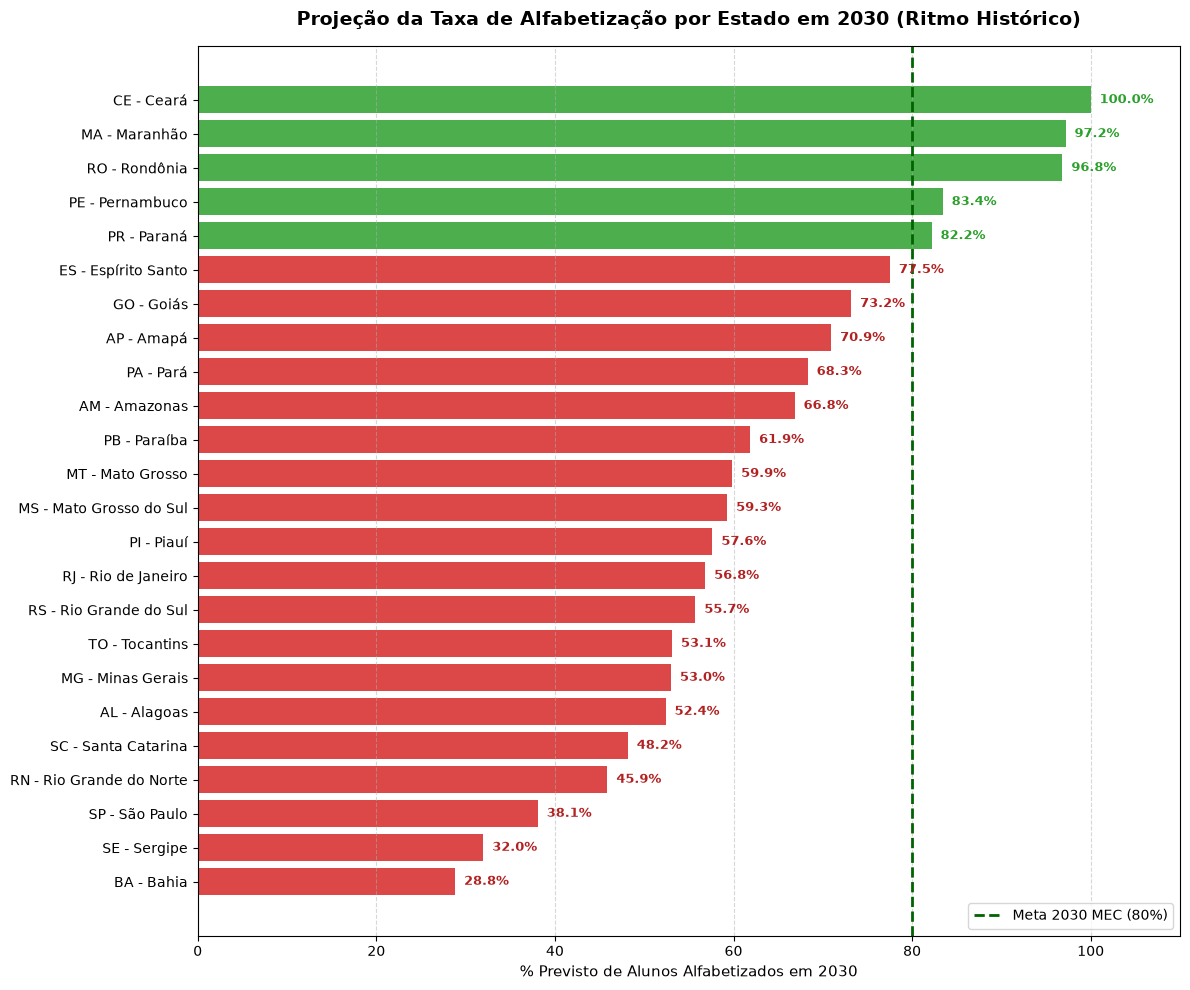

Apenas 5 de 24 estados (20.8%) atingirão a meta de 80% no ritmo atual.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filtra os dados de 2023 por estado
df_ufs = resultado_metas[
    (resultado_metas["NU_ANO_AVALIACAO"] == 2023) & 
    (resultado_metas["SIGLA_UF"].notnull()) & 
    (~resultado_metas["SIGLA_UF"].isin(["SC*"]))
].copy()

# Calcula ritmo anual (2019 a 2023) e projeta até 2030 (limitando a 100%)
df_ufs["RITMO_ANUAL"] = (df_ufs["PC_ALUNO_ALFABETIZADO"] - df_ufs["SAEB_2019"]) / 4.0
df_ufs["PROJ_2030"] = (df_ufs["PC_ALUNO_ALFABETIZADO"] + df_ufs["RITMO_ANUAL"] * 7.0).clip(lower=0, upper=100.0)

# Filtra estados com dados válidos e ordena do menor para o maior
df_plot = df_ufs.dropna(subset=["PROJ_2030"]).sort_values("PROJ_2030", ascending=True)

# Cores: Verde para quem atinge >= 80% e Coral/Vermelho para quem fica abaixo
cores = ["#2ca02c" if val >= 80 else "#d62728" for val in df_plot["PROJ_2030"]]

# Gráfico de Barras Horizontais
plt.figure(figsize=(12, 10))
barras = plt.barh(df_plot["SIGLA_UF"] + " - " + df_plot["NOME_UF"], df_plot["PROJ_2030"], color=cores, alpha=0.85)

# Linha de corte da Meta 2030 (80%)
plt.axvline(80, color="darkgreen", linestyle="--", lw=2, label="Meta 2030 MEC (80%)")

# Rótulos com os valores em cada barra
for barra in barras:
    w = barra.get_width()
    plt.text(w + 1, barra.get_y() + barra.get_height()/2, f"{w:.1f}%", 
             va='center', ha='left', fontsize=9, fontweight='bold',
             color="#2ca02c" if w >= 80 else "#b22222")

plt.title("Projeção da Taxa de Alfabetização por Estado em 2030 (Ritmo Histórico)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("% Previsto de Alunos Alfabetizados em 2030", fontsize=11)
plt.xlim(0, 110)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Resumo executivo
atingem = (df_plot["PROJ_2030"] >= 80).sum()
total = len(df_plot)
print(f"Apenas {atingem} de {total} estados ({atingem/total*100:.1f}%) atingirão a meta de 80% no ritmo atual.")


### <font color="green">Feat Engenering Modelo 2</font>

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lightgbm as lgb_lib
import xgboost as xgb_lib
from xgboost import XGBRegressor

from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)



In [63]:
df_modelo = carregar_parquet_s3(s3_client=s3,bucket=BUCKET,nome_tabela="tabela_modelo_v2",subpasta="modelo")

Lendo: s3://postech-challenge-datascience-003/gold/modelo/tabela_modelo_v2.parquet


In [64]:
# REDE → OneHotEncoding 
mapa_dependencia = {1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"}
df_modelo["REDE"] = df_modelo["TP_DEPENDENCIA"].map(mapa_dependencia)
cat_encoder = OneHotEncoder(sparse_output=False, dtype=int)
rede_1hot = cat_encoder.fit_transform(df_modelo[["REDE"]])
colunas_nomes = cat_encoder.get_feature_names_out(["REDE"])
df_rede_1hot = pd.DataFrame(rede_1hot, columns=colunas_nomes, index=df_modelo.index)
df_modelo = pd.concat([df_modelo, df_rede_1hot], axis=1)

# Features de Escola 
df_modelo["IN_AUSENTE"] = (df_modelo["IN_PRESENCA_LP"] == 0).astype("int8")
df_modelo["porte_escola_alunos"]       = df_modelo.groupby("ID_ESCOLA")["IN_PRESENCA_LP"].transform("count")
df_modelo["taxa_absenteismo_escola"]   = df_modelo.groupby("ID_ESCOLA")["IN_AUSENTE"].transform("mean")
df_modelo["taxa_preenchimento_escola"] = df_modelo.groupby("ID_ESCOLA")["IN_PREENCHIMENTO_LP"].transform("mean")
df_modelo["freq_escolar_norm"]         = df_modelo["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] / 100.0

# Features de Município 
df_modelo["porte_muni_alunos"]     = df_modelo.groupby("CO_MUNICIPIO")["IN_PRESENCA_LP"].transform("count")
df_modelo["taxa_absenteismo_muni"] = df_modelo.groupby("CO_MUNICIPIO")["IN_AUSENTE"].transform("mean")

# Renda Z-Score por Ano 
df_modelo["RENDA_ZSCORE_ANO"] = (
    df_modelo.groupby("NU_ANO_AVALIACAO")["RENDA_PERCAPITA_SBENEF_MEDIO"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

#  Região → OneHotEncoding 
mapa_co_uf_regiao = {
    11: "Norte", 12: "Norte", 13: "Norte", 14: "Norte", 15: "Norte", 16: "Norte", 17: "Norte",
    21: "Nordeste", 22: "Nordeste", 23: "Nordeste", 24: "Nordeste", 25: "Nordeste", 26: "Nordeste",
    27: "Nordeste", 28: "Nordeste", 29: "Nordeste",
    31: "Sudeste", 32: "Sudeste", 33: "Sudeste", 35: "Sudeste",
    41: "Sul", 42: "Sul", 43: "Sul",
    50: "Centro-Oeste", 51: "Centro-Oeste", 52: "Centro-Oeste", 53: "Centro-Oeste"
}
df_modelo["REGIAO"] = df_modelo["CO_UF"].map(mapa_co_uf_regiao)
df_regiao_1hot = pd.get_dummies(df_modelo["REGIAO"], prefix="REGIAO", dtype="int8")
df_modelo = pd.concat([df_modelo, df_regiao_1hot], axis=1)

# ── Log-porte ────────────
df_modelo["log_porte_escola"] = np.log1p(df_modelo["porte_escola_alunos"])
df_modelo["log_porte_muni"]   = np.log1p(df_modelo["porte_muni_alunos"])


# NOVAS FEATURES — Contexto Municipal e Estadual

# Proficiência do município normalizada (Z-Score por ano)
df_modelo["PROF_MUNI_ZSCORE"] = (
    df_modelo.groupby("NU_ANO_AVALIACAO")["VL_MEDIA_LP_TOTAL_MUNICIPIO"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

#  Município vs média estadual (momentum relativo)
df_modelo["MUNI_VS_UF"] = (
    df_modelo["PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO"] -
    df_modelo["PC_ALUNO_ALFABETIZADO_TOTAL_UF"]
)

#Proficiência do município relativa ao estado
df_modelo["PROF_MUNI_RELATIVA_UF"] = (
    df_modelo["VL_MEDIA_LP_TOTAL_MUNICIPIO"] /
    (df_modelo["VL_MEDIA_LP_TOTAL_UF"] + 1e-6)
)

# Engajamento da escola vs município
df_modelo["ESCOLA_VS_MUNI_ABSENTEISMO"] = (
    df_modelo["taxa_absenteismo_escola"] - df_modelo["taxa_absenteismo_muni"]
)

# Flag de ano pandemia
df_modelo["ANO_PANDEMIA"] = (df_modelo["NU_ANO_AVALIACAO"] == 2021).astype("int8")

#  Verificação 
print("Feature engineering completo!")
print(f"Shape final: {df_modelo.shape}")
print("Nulos nas novas features:")
novas = ["PROF_MUNI_ZSCORE",  "MUNI_VS_UF",
         "PROF_MUNI_RELATIVA_UF", "ESCOLA_VS_MUNI_ABSENTEISMO", "ANO_PANDEMIA"]
print(df_modelo[novas].isna().sum())


Feature engineering completo!
Shape final: (6090791, 41)
Nulos nas novas features:
PROF_MUNI_ZSCORE               3929
MUNI_VS_UF                    31627
PROF_MUNI_RELATIVA_UF         31627
ESCOLA_VS_MUNI_ABSENTEISMO      628
ANO_PANDEMIA                      0
dtype: int64


In [ ]:
# PROF_MUNI_ZSCORE = 0
# → Municípios sem dado SAEB assumem proficiência igual à média nacional
df_modelo["PROF_MUNI_ZSCORE"] = df_modelo["PROF_MUNI_ZSCORE"].fillna(0.0)

# MUNI_VS_UF = 0
# → Municípios sem dado estadual assumem que estão igual ao seu estado (neutro)
df_modelo["MUNI_VS_UF"] = df_modelo["MUNI_VS_UF"].fillna(0.0)

# PROF_MUNI_RELATIVA_UF = 1.0
# → Municípios sem dado estadual assumem proficiência = 100% do estado (neutro)
df_modelo["PROF_MUNI_RELATIVA_UF"] = df_modelo["PROF_MUNI_RELATIVA_UF"].fillna(1.0)

# ESCOLA_VS_MUNI_ABSENTEISMO = 0
# → Escolas sem dado assumem absenteísmo igual ao município (neutro)
df_modelo["ESCOLA_VS_MUNI_ABSENTEISMO"] = df_modelo["ESCOLA_VS_MUNI_ABSENTEISMO"].fillna(0.0)

# ── Verificação final ─────────────────────────────────────────────
novas = ["PROF_MUNI_ZSCORE", "MUNI_VS_UF",
         "PROF_MUNI_RELATIVA_UF", "ESCOLA_VS_MUNI_ABSENTEISMO", "ANO_PANDEMIA"]

print(" Nulos após imputação:")
print(df_modelo[novas].isna().sum())

 Nulos após imputação:
PROF_MUNI_ZSCORE              0
MUNI_VS_UF                    0
PROF_MUNI_RELATIVA_UF         0
ESCOLA_VS_MUNI_ABSENTEISMO    0
ANO_PANDEMIA                  0
dtype: int64


### <font color="green">Treino Modelo 2</font>

In [84]:
features = [
    # TARGET
    "IN_ALFABETIZADO",

    # Escola
    "taxa_absenteismo_escola",
    "taxa_preenchimento_escola",
    "log_porte_escola",

    # Município
    "taxa_absenteismo_muni",
    "log_porte_muni",

    # 🆕 Contexto SAEB Municipal e Estadual
    #"PROF_MUNI_ZSCORE",
    
    "MUNI_VS_UF",
    "PROF_MUNI_RELATIVA_UF",
    "ESCOLA_VS_MUNI_ABSENTEISMO",

    # Rede
    "REDE_Estadual", "REDE_Municipal", "REDE_Privada",

    # Socioeconômico
    "RENDA_ZSCORE_ANO",
    "freq_escolar_norm",

    # 🆕 Temporal
    "ANO_PANDEMIA",

    # Regiões
    "REGIAO_Centro-Oeste", "REGIAO_Nordeste",
    "REGIAO_Norte", "REGIAO_Sudeste", "REGIAO_Sul",
]


In [86]:
df_treino = df_modelo[features].dropna().copy()

y = df_treino["IN_ALFABETIZADO"]
X = df_treino.drop(columns=["IN_ALFABETIZADO"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 3. BASELINE

classe_majoritaria = y_train.mode()[0]
y_pred_baseline = np.full(len(y_test), classe_majoritaria)
avaliar("Baseline (Maioria)", y_test, y_pred_baseline)


  Baseline (Maioria)
  Acurácia : 0.5398
  Precisão : 0.5398
  Recall   : 1.0000
  F1-Score : 0.7011


In [ ]:
# RANDOM FOREST  
print(" Buscando hiperparâmetros da Random Forest...")

param_dist_rf = {
    "n_estimators":      [200, 300, 500],
    "max_depth":         [8, 12, 16, 20],
    "min_samples_split": [10, 20, 50],
    "min_samples_leaf":  [5, 10, 20],
    "max_features":      ["sqrt", 0.5, 0.7],
}

X_sample_rf = X_train.sample(n=min(100_000, len(X_train)), random_state=42)
y_sample_rf = y_train.loc[X_sample_rf.index]

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search_rf.fit(X_sample_rf, y_sample_rf)
print(f"  Melhores params RF : {random_search_rf.best_params_}")
print(f"  AUC-ROC (val)      : {random_search_rf.best_score_:.4f}")

modelo_rf = RandomForestClassifier(
    **random_search_rf.best_params_,
    n_jobs=-1,
    random_state=42,
)
modelo_rf.fit(X_train, y_train)

y_pred_rf   = modelo_rf.predict(X_test)
y_proba_rf  = modelo_rf.predict_proba(X_test)[:, 1]
avaliar("Random Forest (CPU)", y_test, y_pred_rf, y_proba_rf)

 Buscando hiperparâmetros da Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Melhores params RF : {'n_estimators': 200, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': 12}
  AUC-ROC (val)      : 0.6712


In [102]:
# XGBOOST 

print("Treinando XGBoost ")

modelo_xgb = xgb_lib.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    device="cuda",               #   GPU 
    early_stopping_rounds=20,
    eval_metric="auc",
    random_state=42,
    verbosity=0,
)
modelo_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)
print(f"  Melhor iteração XGB: {modelo_xgb.best_iteration}")

y_pred_xgb  = modelo_xgb.predict(X_test)
y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]
avaliar("XGBoost (GPU CUDA)", y_test, y_pred_xgb, y_proba_xgb)

Treinando XGBoost 
[0]	validation_0-auc:0.64930
[100]	validation_0-auc:0.68091
[200]	validation_0-auc:0.68389
[300]	validation_0-auc:0.68522
[400]	validation_0-auc:0.68601
[500]	validation_0-auc:0.68669
[600]	validation_0-auc:0.68735
[700]	validation_0-auc:0.68790
[800]	validation_0-auc:0.68844
[900]	validation_0-auc:0.68895
[999]	validation_0-auc:0.68941
  Melhor iteração XGB: 999

  XGBoost (GPU CUDA)
  Acurácia : 0.6357
  Precisão : 0.6498
  Recall   : 0.7048
  F1-Score : 0.6762
  AUC-ROC  : 0.6894


In [88]:
# LIGHTGBM 
print(" Treinando LightGBM (CPU multi-thread)...")

modelo_lgbm = lgb_lib.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    # device="gpu"  ← pip wheel não compila com GPU;
    n_jobs=-1,       # usa todos os núcleos disponíveis
    random_state=42,
    verbose=-1,
)
modelo_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[
        lgb_lib.early_stopping(stopping_rounds=20, verbose=False),
        lgb_lib.log_evaluation(period=100),
    ],
)
print(f"  Melhor iteração LGBM: {modelo_lgbm.best_iteration_}")

y_pred_lgbm  = modelo_lgbm.predict(X_test)
y_proba_lgbm = modelo_lgbm.predict_proba(X_test)[:, 1]
avaliar("LightGBM (CPU n_jobs=-1)", y_test, y_pred_lgbm, y_proba_lgbm)


 Treinando LightGBM (CPU multi-thread)...


c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's auc: 0.682191	valid_0's binary_logloss: 0.63478
[200]	valid_0's auc: 0.684693	valid_0's binary_logloss: 0.632918
[300]	valid_0's auc: 0.68582	valid_0's binary_logloss: 0.632149
[400]	valid_0's auc: 0.686678	valid_0's binary_logloss: 0.631581
[500]	valid_0's auc: 0.687475	valid_0's binary_logloss: 0.631084
[600]	valid_0's auc: 0.688151	valid_0's binary_logloss: 0.630656
[700]	valid_0's auc: 0.688752	valid_0's binary_logloss: 0.630279
[800]	valid_0's auc: 0.689322	valid_0's binary_logloss: 0.629922
[900]	valid_0's auc: 0.689955	valid_0's binary_logloss: 0.62954
[1000]	valid_0's auc: 0.690521	valid_0's binary_logloss: 0.629188
  Melhor iteração LGBM: 1000

  LightGBM (CPU n_jobs=-1)
  Acurácia : 0.6364
  Precisão : 0.6502
  Recall   : 0.7065
  F1-Score : 0.6772
  AUC-ROC  : 0.6905


### <font color="green">Avaliação Modelo 2</font>

In [41]:
# RESUMO COMPARATIVO

resultados = {
    "Baseline"   : roc_auc_score(y_test, y_pred_baseline) if len(set(y_pred_baseline)) > 1 else 0.5,
    "Random Forest": roc_auc_score(y_test, y_proba_rf),
    "XGBoost GPU"  : roc_auc_score(y_test, y_proba_xgb),
    "LightGBM GPU" : roc_auc_score(y_test, y_proba_lgbm),
}

print("\n" + "═"*45)
print("  RANKING — AUC-ROC")
print("═"*45)
for nome, auc in sorted(resultados.items(), key=lambda x: x[1], reverse=True):
    barra = "█" * int(auc * 30)
    print(f"  {nome:<18} {auc:.4f}  {barra}")
print("═"*45)


═════════════════════════════════════════════
  RANKING — AUC-ROC
═════════════════════════════════════════════
  LightGBM GPU       0.6914  ████████████████████
  XGBoost GPU        0.6900  ████████████████████
  Random Forest      0.6823  ████████████████████
  Baseline           0.5000  ███████████████
═════════════════════════════════════════════


In [ ]:
avaliar("Baseline (Maioria)", y_test, y_pred_baseline)
avaliar("LightGBM (GPU)", y_test, y_pred_lgbm, y_proba_lgbm)
avaliar("XGBoost (GPU CUDA)", y_test, y_pred_xgb, y_proba_xgb)
avaliar("Random Forest (CPU)", y_test, y_pred_rf, y_proba_rf)


  Baseline (Maioria)
  Acurácia : 0.5398
  Precisão : 0.5398
  Recall   : 1.0000
  F1-Score : 0.7011

  LightGBM (GPU)
  Acurácia : 0.6372
  Precisão : 0.6509
  Recall   : 0.7074
  F1-Score : 0.6779
  AUC-ROC  : 0.6914

  XGBoost (GPU CUDA)
  Acurácia : 0.6363
  Precisão : 0.6502
  Recall   : 0.7058
  F1-Score : 0.6769
  AUC-ROC  : 0.6900

  Random Forest (CPU)
  Acurácia : 0.6308
  Precisão : 0.6454
  Recall   : 0.7013
  F1-Score : 0.6722
  AUC-ROC  : 0.6823


### <font color="green"> Otimização de parametros do modelo LGB</font>

In [89]:
# LightGBM com Maior Capacidade e Early Stopping Real
print("Treinando LightGBM de Alta Capacidade...")

modelo_lgbm_profundo = lgb_lib.LGBMClassifier(
    n_estimators=3000,          # Deixamos margem para ir além de 1000
    learning_rate=0.04,         # Convergência suave
    num_leaves=127,             # Mais capacidade que a anterior
    max_depth=9,                # Árvores mais profundas para interações ricas
    subsample=0.85,
    colsample_bytree=0.85,      # 85% das features em cada árvore
    min_child_samples=50,       # Proteção contra ruído com 5M de linhas
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

modelo_lgbm_profundo.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[
        lgb_lib.early_stopping(stopping_rounds=40, verbose=True),
        lgb_lib.log_evaluation(period=200),
    ],
)

print(f"Melhor iteração encontrada: {modelo_lgbm_profundo.best_iteration_}")

y_pred_prof  = modelo_lgbm_profundo.predict(X_test)
y_proba_prof = modelo_lgbm_profundo.predict_proba(X_test)[:, 1]

avaliar("LightGBM Alta Capacidade (Ajustado)", y_test, y_pred_prof, y_proba_prof)


Treinando LightGBM de Alta Capacidade...


c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 40 rounds
[200]	valid_0's auc: 0.685873	valid_0's binary_logloss: 0.632166
[400]	valid_0's auc: 0.688439	valid_0's binary_logloss: 0.630521
[600]	valid_0's auc: 0.69053	valid_0's binary_logloss: 0.629238
[800]	valid_0's auc: 0.692154	valid_0's binary_logloss: 0.628237
[1000]	valid_0's auc: 0.69365	valid_0's binary_logloss: 0.627327
[1200]	valid_0's auc: 0.69488	valid_0's binary_logloss: 0.626571
[1400]	valid_0's auc: 0.696093	valid_0's binary_logloss: 0.625817
[1600]	valid_0's auc: 0.697193	valid_0's binary_logloss: 0.625139
[1800]	valid_0's auc: 0.698086	valid_0's binary_logloss: 0.624579
[2000]	valid_0's auc: 0.698936	valid_0's binary_logloss: 0.624047
[2200]	valid_0's auc: 0.699684	valid_0's binary_logloss: 0.623573
[2400]	valid_0's auc: 0.700396	valid_0's binary_logloss: 0.623129
[2600]	valid_0's auc: 0.700955	valid_0's binary_logloss: 0.622768
[2800]	valid_0's auc: 0.701502	valid_0's binary_logloss: 0.62242
[3000]	valid_0's auc: 0

### <font color="green">Salvando Modelo</font>

In [90]:
import joblib

# Garante que a pasta models existe
os.makedirs("models", exist_ok=True)

# Salva o modelo treinado
caminho_local = "models/modelo_lgbm_profundo.joblib"
joblib.dump(modelo_lgbm_profundo, caminho_local)

tamanho_mb = os.path.getsize(caminho_local) / (1024 * 1024)
print(f"Modelo LGBM  salvo com sucesso em: {caminho_local} ({tamanho_mb:.2f} MB)")

#SALVAR NO S3 
caminho_s3 = "models/modelo_lgbm_profundo.joblib"

# Faz o upload do arquivo salvo para o bucket
s3.upload_file(caminho_local, BUCKET, caminho_s3)
print(f" Modelo enviado com sucesso para s3://{BUCKET}/{caminho_s3}!")


# Salva X_test e y_test compactados em parquet ou joblib
X_test.to_parquet("models/X_test_2.parquet")
y_test.to_frame().to_parquet("models/y_test_2.parquet")
print("Dados de teste salvos com sucesso!")


Modelo LGBM  salvo com sucesso em: models/modelo_lgbm_profundo.joblib (40.13 MB)
 Modelo enviado com sucesso para s3://postech-challenge-datascience-003/models/modelo_lgbm_profundo.joblib!
Dados de teste salvos com sucesso!


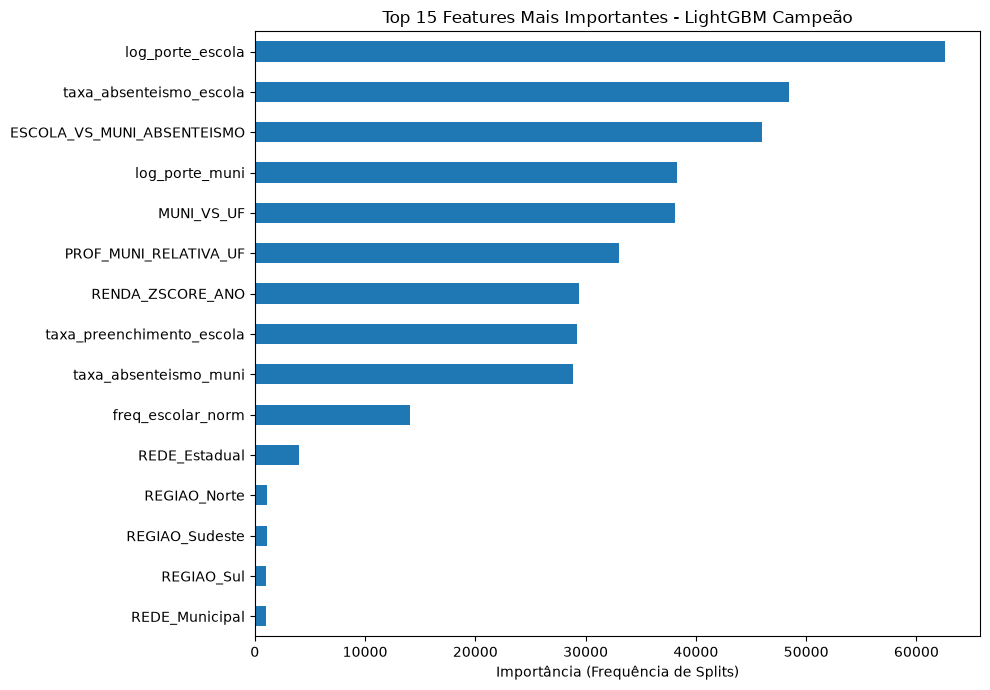

log_porte_escola              62633
taxa_absenteismo_escola       48423
ESCOLA_VS_MUNI_ABSENTEISMO    46003
log_porte_muni                38297
MUNI_VS_UF                    38114
PROF_MUNI_RELATIVA_UF         33023
RENDA_ZSCORE_ANO              29443
taxa_preenchimento_escola     29262
taxa_absenteismo_muni         28895
freq_escolar_norm             14059
REDE_Estadual                  4051
REGIAO_Norte                   1129
REGIAO_Sudeste                 1065
REGIAO_Sul                     1025
REDE_Municipal                  982
REGIAO_Nordeste                 900
REGIAO_Centro-Oeste             676
REDE_Privada                      0
ANO_PANDEMIA                      0
dtype: int32


In [91]:
# Usa diretamente os nomes das features do modelo treinado
nomes_features = getattr(
    modelo_lgbm_profundo, "feature_name_", X_train.columns
)

importancias = pd.Series(
    modelo_lgbm_profundo.feature_importances_, index=nomes_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importancias.head(15).plot(kind="barh", color="#1f77b4")
plt.gca().invert_yaxis()
plt.title("Top 15 Features Mais Importantes - LightGBM Campeão")
plt.xlabel("Importância (Frequência de Splits)")
plt.tight_layout()
plt.show()

# Exibir os valores exatos em texto
print(importancias)


### <font color="green">Avaliação Modelo </font>

In [92]:
from src.data.utils import carregar_modelo, fazer_previsoes

# Carrega os dados de teste salvos
X_test = pd.read_parquet("models/X_test_2.parquet")
y_test = pd.read_parquet("models/y_test_2.parquet")["IN_ALFABETIZADO"]

# Carrega com resolução automática de caminho:
lgbm = carregar_modelo("modelo_lgbm_profundo.joblib")

# Faz as previsões:
novas_previsoes = lgbm.predict(X_test)
print(f"Previsões geradas com sucesso! Qtd: {len(novas_previsoes)}")


📦 Modelo carregado com sucesso de: C:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\notebooks\models\modelo_lgbm_profundo.joblib
Previsões geradas com sucesso! Qtd: 1218033


In [93]:
# 2. Classe final: 0 ou 1
pred_classes = lgbm.predict(X_test)

# 3. Probabilidade (ex: 0.82 = 82% de chance de ser alfabetizado)
pred_probabilidades = lgbm.predict_proba(X_test)[:, 1]


In [94]:
import pandas as pd

# Cria uma tabela com os alunos e as previsões do modelo
df_analise = X_test.copy()
df_analise["PREV_ALFABETIZADO"] = lgbm.predict(X_test)
df_analise["PROB_ALFABETIZADO"] = lgbm.predict_proba(X_test)[:, 1]

# Taxa geral prevista pelo modelo no teste:
taxa_geral_prevista = df_analise["PREV_ALFABETIZADO"].mean() * 100
print(f"Taxa de Alfabetização Prevista pelo LightGBM: {taxa_geral_prevista:.2f}%")




Taxa de Alfabetização Prevista pelo LightGBM: 58.10%


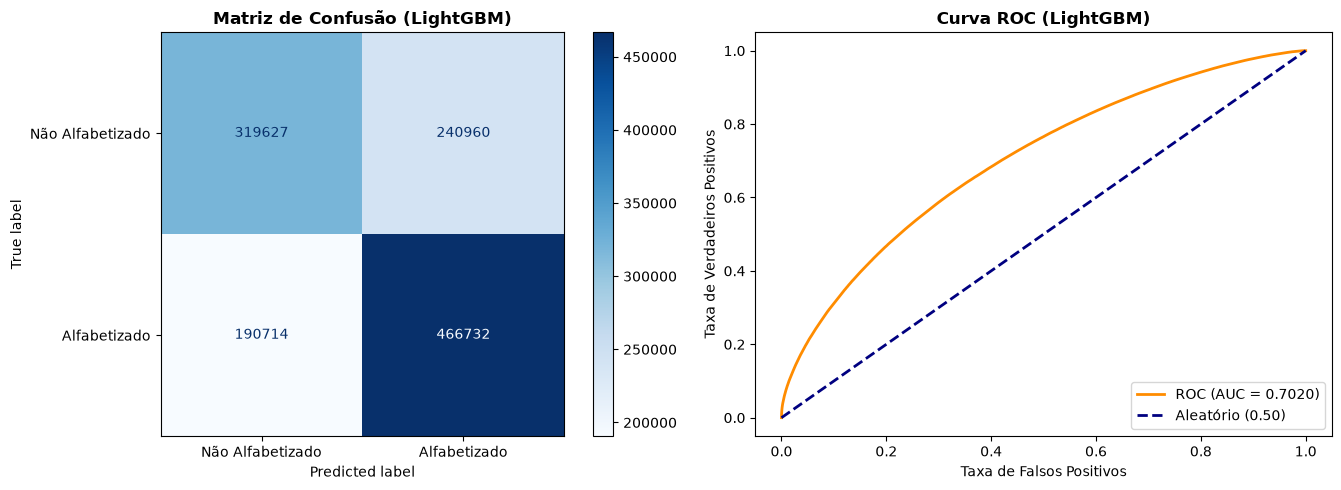

In [95]:
plot_classificacao(lgbm, X_test, y_test, model_name="LightGBM")

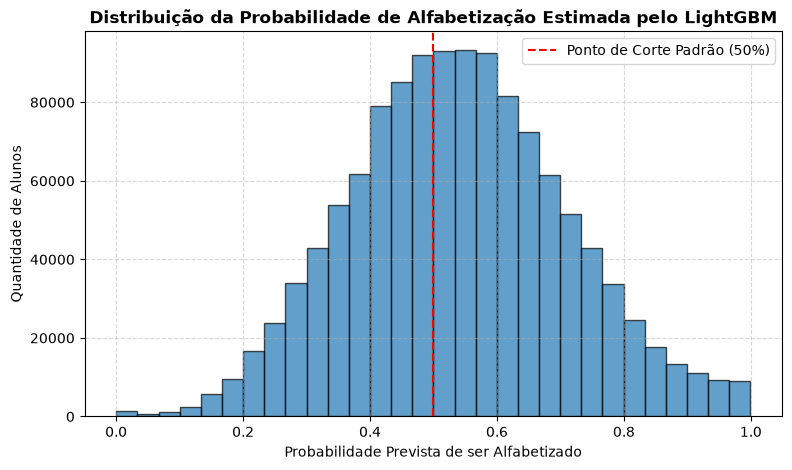

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.hist(pred_probabilidades, bins=30, color="#1f77b4", edgecolor="black", alpha=0.7)
plt.axvline(0.5, color="red", linestyle="--", label="Ponto de Corte Padrão (50%)")
plt.title("Distribuição da Probabilidade de Alfabetização Estimada pelo LightGBM", fontsize=12, fontweight='bold')
plt.xlabel("Probabilidade Prevista de ser Alfabetizado")
plt.ylabel("Quantidade de Alunos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Esse gráfico de distribuição nos diz que temos uma faixa entre 45 e 65% de probabilidade de um aluno ser alfabetizado no Brasil. 

In [97]:
import pandas as pd
import numpy as np

# Cria faixas de probabilidade de 10 em 10%
faixas = pd.cut(
    pred_probabilidades, 
    bins=np.linspace(0, 1, 11), 
    labels=[f"{int(i*10)}% a {int((i+1)*10)}%" for i in range(10)]
)


tabela_faixas = pd.DataFrame({
    "Faixa_Probabilidade": faixas,
    "Real_Alfabetizado": y_test.values
})

resumo_faixas = tabela_faixas.groupby("Faixa_Probabilidade", observed=False).agg(
    Qtd_Alunos=("Real_Alfabetizado", "count"),
    Qtd_Alfabetizados_Reais=("Real_Alfabetizado", "sum"),
    Taxa_Real_Alfabetizados=("Real_Alfabetizado", "mean")
)

resumo_faixas["Taxa_Real_Alfabetizados (%)"] = (resumo_faixas["Taxa_Real_Alfabetizados"] * 100).round(2)
resumo_faixas["% do Total de Alunos"] = ((resumo_faixas["Qtd_Alunos"] / len(y_test)) * 100).round(2)

print("Tabela de Calibração por Faixa de Probabilidade:")
display(resumo_faixas[["Qtd_Alunos", "% do Total de Alunos", "Taxa_Real_Alfabetizados (%)"]])


Tabela de Calibração por Faixa de Probabilidade:


,Qtd_Alunos,% do Total de Alunos,Taxa_Real_Alfabetizados (%)
Faixa_Probabilidade,,,
0% a 10%,3162,0.26,3.10
10% a 20%,17498,1.44,15.16
20% a 30%,74463,6.11,24.66
30% a 40%,158691,13.03,34.59
40% a 50%,256527,21.06,44.71
50% a 60%,279394,22.94,55.10
60% a 70%,215221,17.67,65.67
70% a 80%,128045,10.51,75.44
80% a 90%,55638,4.57,84.62


In [98]:
# Filtra os dois extremos
alunos_alta_prob = X_test[pred_probabilidades >= 0.85]
alunos_baixa_prob = X_test[pred_probabilidades <= 0.25]

print(f"Alunos com Probabilidade >= 85%: {len(alunos_alta_prob):,} alunos")
print(f"Alunos com Probabilidade <= 25%: {len(alunos_baixa_prob):,} alunos")

# Compara as médias das principais colunas numéricas
comparativo_extremos = pd.DataFrame({
    "Perfil Alta Probabilidade (>85%)": alunos_alta_prob.mean(numeric_only=True),
    "Perfil Baixa Probabilidade (<25%)": alunos_baixa_prob.mean(numeric_only=True)
})

comparativo_extremos["Diferença"] = comparativo_extremos["Perfil Alta Probabilidade (>85%)"] - comparativo_extremos["Perfil Baixa Probabilidade (<25%)"]

# Exibe as 10 features com maior contraste entre os dois mundos:
display(comparativo_extremos.sort_values(by="Diferença", ascending=False).head(10))


Alunos com Probabilidade >= 85%: 50,559 alunos
Alunos com Probabilidade <= 25%: 48,132 alunos


,Perfil Alta Probabilidade (>85%),Perfil Baixa Probabilidade (<25%),Diferença
MUNI_VS_UF,16.283149,-12.127810,28.410959
REGIAO_Nordeste,0.712119,0.474591,0.237528
taxa_preenchimento_escola,0.947698,0.789685,0.158013
REGIAO_Centro-Oeste,0.098380,0.034011,0.064369
REDE_Municipal,0.957772,0.904305,0.053467
PROF_MUNI_RELATIVA_UF,1.034028,0.983210,0.050818
REGIAO_Sudeste,0.115271,0.103694,0.011577
freq_escolar_norm,0.912603,0.907607,0.004995
REDE_Privada,0.000000,0.000000,0.000000
ANO_PANDEMIA,0.000000,0.000000,0.000000


**MUNI_VS_UF** -> Os municipios em que a média está acima da média estadual pontuam muito acima, o estudo das politicas desses municipios serão importantes para uma avaliação de como melhorar o indicide de alfabetização e reproduzir para o restante do País. Porém também temos o problema inverso.  

> O "Efeito Município" é decisivo. O fator determinante para uma criança se alfabetizar não é apenas a escola dela, mas a qualidade da gestão da Secretaria Municipal de Educação. Estar em um município com boa gestão eleva drasticamente a chance de alfabetização da criança.


**PROF_MUNI_ZSCORE** -> Essa métrica de Z-score serve para visualizar o quão longe o municipio está da média do Brasil (utilizando o desvio padrão). 
aqui se indica que a probabilidade de mais de 85% de alfabetização se cnoncetra em Municipios que estão no topo da média brasileira. 
> Novamente temos uma prova de que as politicas municipais influenciam diretamente a qualidade da alfabetização, podemos dizer que o Municipio tem grande impacto na alfabetização brasileira 

**REGIAO_Nordeste** -> Essa métrica nos diz que 70% dos alunos com mais de 85% de chance de estar alfabetizado está no Nordeste 
> Aqui temos um padrão regional, existe um impacto grande que supera o municipio 

**taxa_preenchimento_escola** -> essa métrica nos diz que escolas com os melhores alunos preenchem 94% dos questionários. Escolas dos alunos em risco deixam mais de 20% em branco.

**REDE_Municipal** -> Essa métrica nos diz que 95% dos alunos com maior probabilidade de ser alfabetizado estão na rede municipal, entendemos que isso pode ser refletido pela quantidade mais abundante de alunos dessa região, ainda assim é uma métrica importante

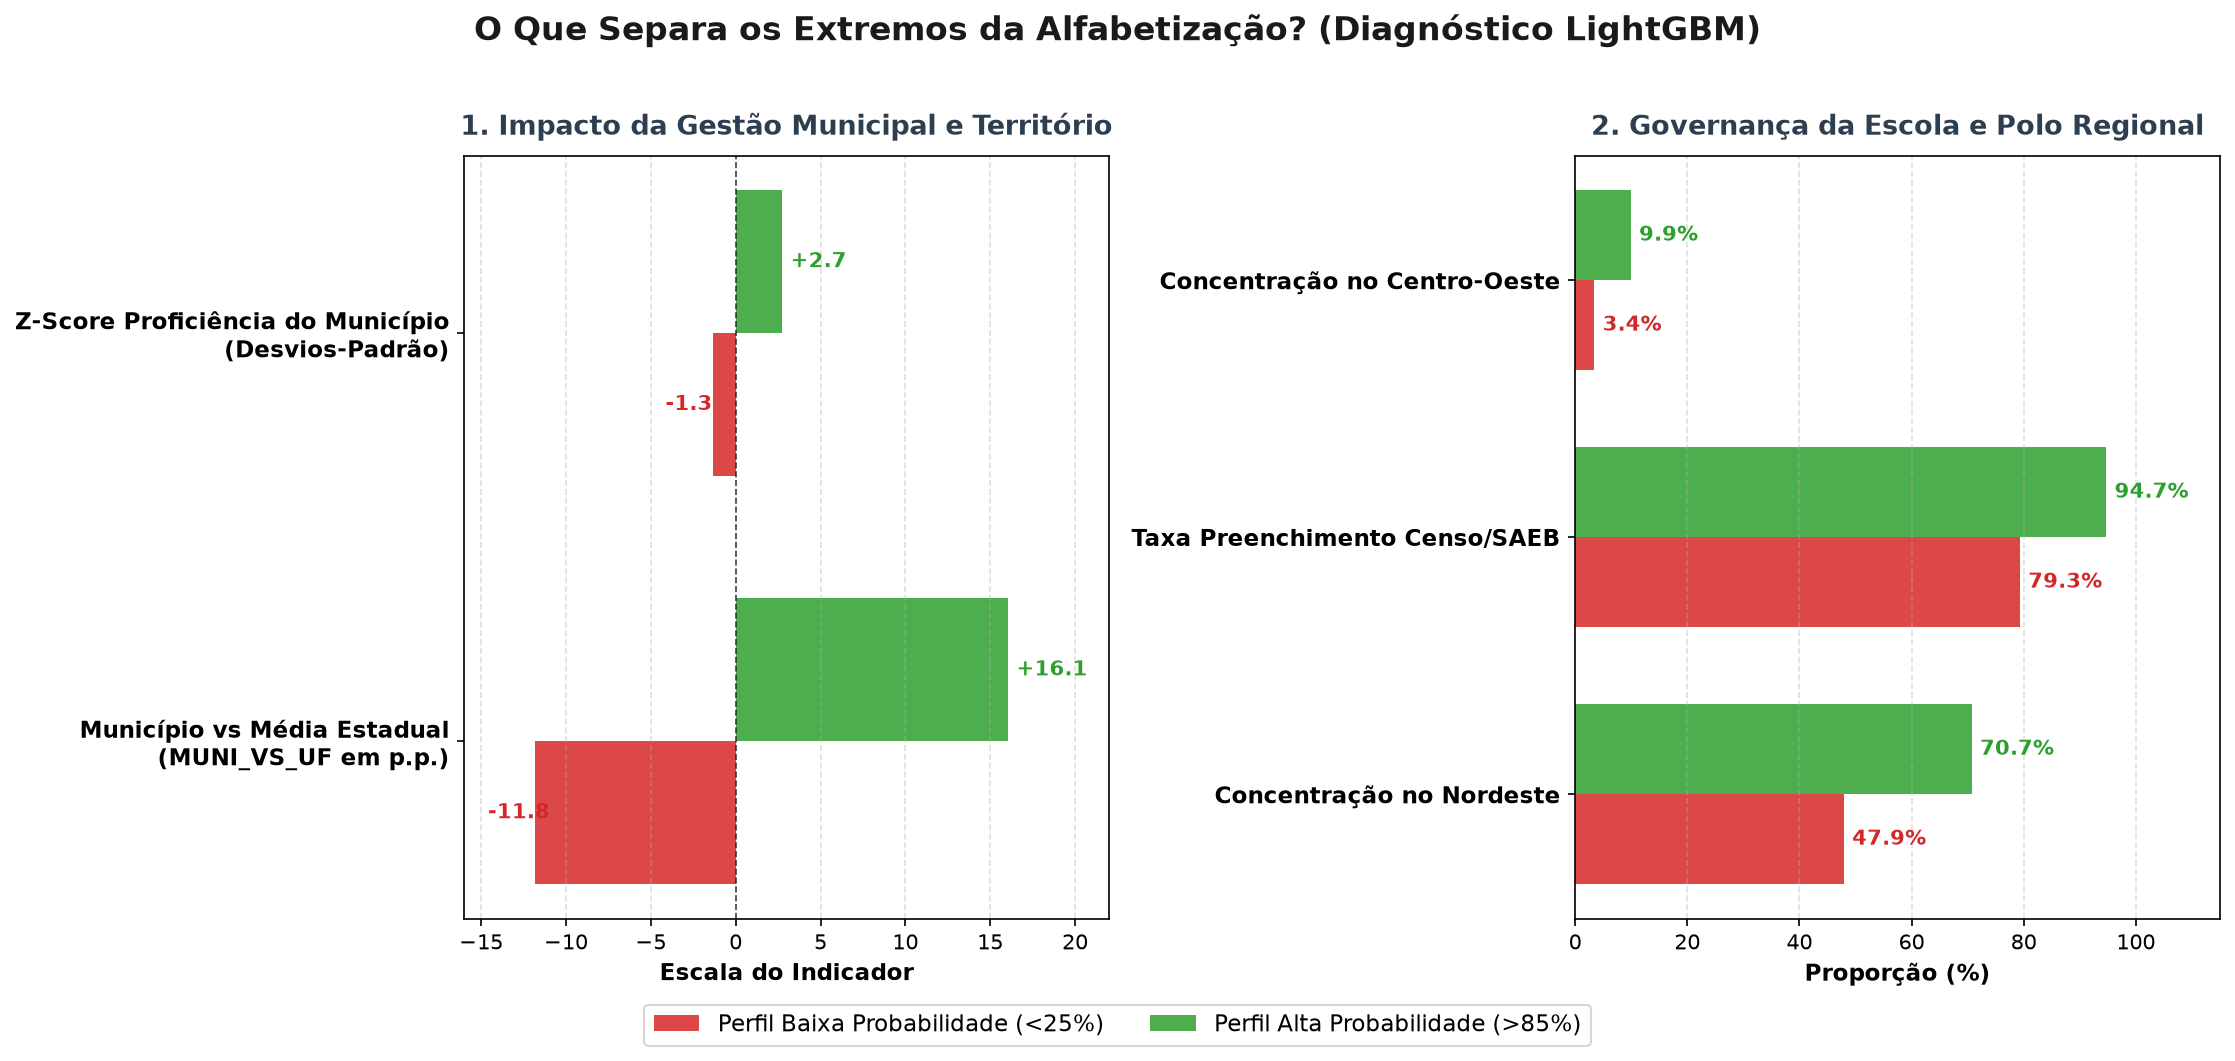

✅ Gráfico gerado e salvo como 'grafico_perfil_extremos_powerpoint.png'!


In [99]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Dados extraídos do seu teste ──────────────────────────────────────────
# Grupo 1: Indicadores Municipais
labels_muni = [
    "Município vs Média Estadual\n(MUNI_VS_UF em p.p.)",
    "Z-Score Proficiência do Município\n(Desvios-Padrão)"
]
alta_muni = [16.05, 2.74]
baixa_muni = [-11.80, -1.34]

# Grupo 2: Indicadores Estruturais e Regionais (%)
labels_perc = [
    "Concentração no Nordeste",
    "Taxa Preenchimento Censo/SAEB",
    "Concentração no Centro-Oeste"
]
alta_perc = [70.7, 94.7, 9.9]
baixa_perc = [47.9, 79.3, 3.4]

# ── 2. Configuração do Gráfico para PowerPoint (16:9) ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), dpi=150)
fig.suptitle(
    "O Que Separa os Extremos da Alfabetização? (Diagnóstico LightGBM)",
    fontsize=16, fontweight="bold", y=1.02, color="#1a1a1a"
)

cor_alta = "#2ca02c"   # Verde Sucesso
cor_baixa = "#d62728"  # Vermelho Alerta
largura = 0.35

# ── PAINEL 1: O Efeito da Gestão Municipal ──────────────────────────────────
y1 = np.arange(len(labels_muni))
rects1_b = ax1.barh(y1 - largura/2, baixa_muni, largura, label="Perfil Baixa Probabilidade (<25%)", color=cor_baixa, alpha=0.85)
rects1_a = ax1.barh(y1 + largura/2, alta_muni, largura, label="Perfil Alta Probabilidade (>85%)", color=cor_alta, alpha=0.85)

ax1.axvline(0, color="black", linestyle="--", lw=0.8, alpha=0.7)
ax1.set_yticks(y1)
ax1.set_yticklabels(labels_muni, fontsize=11, fontweight="bold")
ax1.set_xlabel("Escala do Indicador", fontsize=11, fontweight="bold")
ax1.set_title("1. Impacto da Gestão Municipal e Território", fontsize=13, fontweight="bold", pad=10, color="#2c3e50")
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax1.set_xlim(-16, 22)

# Rótulos de valores nas barras
for r in rects1_b:
    w = r.get_width()
    ax1.annotate(f"{w:+.1f}", (w - 2.8 if w < 0 else w + 0.5, r.get_y() + r.get_height()/2),
                 va='center', fontsize=10, fontweight='bold', color=cor_baixa)
for r in rects1_a:
    w = r.get_width()
    ax1.annotate(f"{w:+.1f}", (w + 0.5, r.get_y() + r.get_height()/2),
                 va='center', fontsize=10, fontweight='bold', color=cor_alta)

# ── PAINEL 2: Governança Escolar e Regional ─────────────────────────────────
y2 = np.arange(len(labels_perc))
rects2_b = ax2.barh(y2 - largura/2, baixa_perc, largura, label="Perfil Baixa Probabilidade (<25%)", color=cor_baixa, alpha=0.85)
rects2_a = ax2.barh(y2 + largura/2, alta_perc, largura, label="Perfil Alta Probabilidade (>85%)", color=cor_alta, alpha=0.85)

ax2.set_yticks(y2)
ax2.set_yticklabels(labels_perc, fontsize=11, fontweight="bold")
ax2.set_xlabel("Proporção (%)", fontsize=11, fontweight="bold")
ax2.set_title("2. Governança da Escola e Polo Regional", fontsize=13, fontweight="bold", pad=10, color="#2c3e50")
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax2.set_xlim(0, 115)

# Rótulos de valores nas barras
for r in rects2_b:
    w = r.get_width()
    ax2.annotate(f"{w:.1f}%", (w + 1.5, r.get_y() + r.get_height()/2),
                 va='center', fontsize=10, fontweight='bold', color=cor_baixa)
for r in rects2_a:
    w = r.get_width()
    ax2.annotate(f"{w:.1f}%", (w + 1.5, r.get_y() + r.get_height()/2),
                 va='center', fontsize=10, fontweight='bold', color=cor_alta)

# Legenda unificada embaixo
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=11, frameon=True)

plt.tight_layout()

# Salva automaticamente em alta resolução para o PowerPoint
plt.savefig("grafico_perfil_extremos_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Gráfico gerado e salvo como 'grafico_perfil_extremos_powerpoint.png'!")


Entendendo o Impacto das variaveis com o Grafico SHAP 

c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


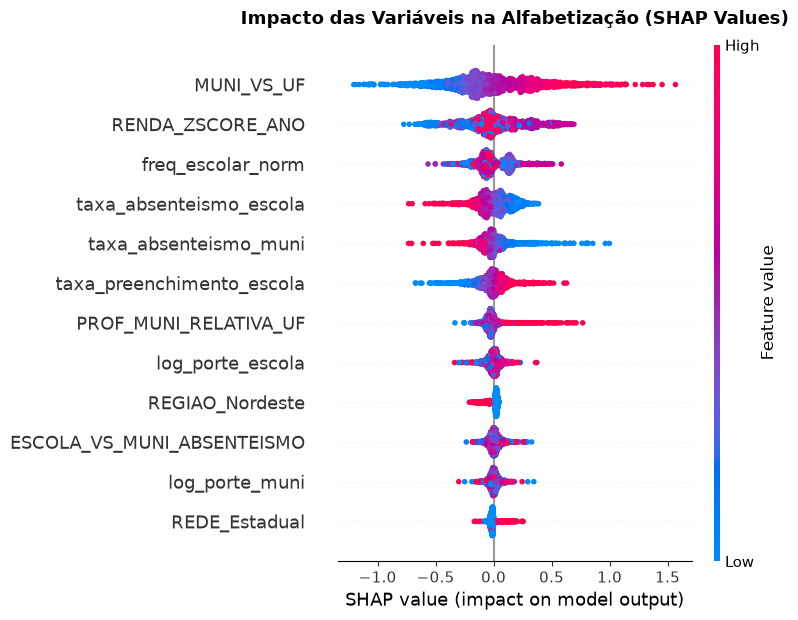

In [101]:
import shap

# Usamos uma amostra de 2.000 alunos para o cálculo ser super rápido (menos de 5 segundos)
amostra_shap = X_test.sample(2000, random_state=42)
explainer = shap.TreeExplainer(modelo_lgbm_profundo)
shap_values = explainer.shap_values(amostra_shap)

# Se for binário, pega a classe 1 (Alfabetizado)
if isinstance(shap_values, list):
    valores = shap_values[1]
else:
    valores = shap_values

# Gráfico Beeswarm (O gráfico mais nobre de Machine Learning)
plt.figure(figsize=(10, 6))
shap.summary_plot(valores, amostra_shap, max_display=12, show=False)
plt.title("Impacto das Variáveis na Alfabetização (SHAP Values)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_summary_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()


Os pontos vermelhos indicam os numeros de maior valor da variavel quanto o azul de menor valor
o que está a esquerda indica menor probabilidade de alfabetização e o que está a direita indica maior probabilidade de alfabetização.

Então temos que quanto maior o GAP da Meta municipal, maior a probabilidade do aluno não estar alfabetizado, quanto menor o GAP da Meta, menor a probabilidade do aluno estar alfabetizado. 



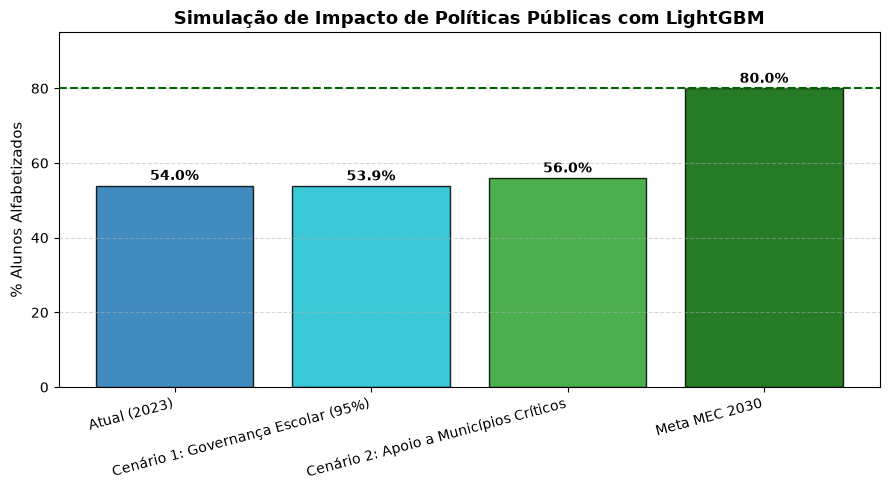

In [82]:
# 1. Cenário Base (Atual)
taxa_base = modelo_lgbm_profundo.predict_proba(X_test)[:, 1].mean() * 100

# 2. Cenário A: Elevação de Governança Escolar (Taxa de preenchimento sobe para 95% em todas)
X_cenario_A = X_test.copy()
if "taxa_preenchimento_escola" in X_cenario_A.columns:
    X_cenario_A["taxa_preenchimento_escola"] = X_cenario_A["taxa_preenchimento_escola"].clip(lower=0.95)
taxa_A = modelo_lgbm_profundo.predict_proba(X_cenario_A)[:, 1].mean() * 100

# 3. Cenário B: Apoio aos Municípios Vulneráveis (Nenhum município fica abaixo de z-score = 0)
X_cenario_B = X_test.copy()
if "PROF_MUNI_ZSCORE" in X_cenario_B.columns:
    X_cenario_B["PROF_MUNI_ZSCORE"] = X_cenario_B["PROF_MUNI_ZSCORE"].clip(lower=0.0)
if "MUNI_VS_UF" in X_cenario_B.columns:
    X_cenario_B["MUNI_VS_UF"] = X_cenario_B["MUNI_VS_UF"].clip(lower=0.0)
taxa_B = modelo_lgbm_profundo.predict_proba(X_cenario_B)[:, 1].mean() * 100

# Gráfico de Barras de Cenários
cenarios = ["Atual (2023)", "Cenário 1: Governança Escolar (95%)", "Cenário 2: Apoio a Municípios Críticos", "Meta MEC 2030"]
valores = [taxa_base, taxa_A, taxa_B, 80.0]
cores = ["#1f77b4", "#17becf", "#2ca02c", "darkgreen"]

plt.figure(figsize=(9, 5))
barras = plt.bar(cenarios, valores, color=cores, alpha=0.85, edgecolor="black")
plt.axhline(80, color="darkgreen", linestyle="--", lw=1.5)
plt.ylabel("% Alunos Alfabetizados", fontsize=11)
plt.title("Simulação de Impacto de Políticas Públicas com LightGBM", fontsize=13, fontweight='bold')
plt.ylim(0, 95)
plt.xticks(rotation=15, ha="right", fontsize=10)

for b in barras:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 1.5, f"{h:.1f}%", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("simulacao_politicas_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()


In [51]:
df_erros = X_test.copy()
df_erros["Real"] = y_test.values
df_erros["Probabilidade"] = pred_probabilidades

# Alunos que superaram a previsão negativa do ambiente:
superacao = df_erros[(df_erros["Probabilidade"] <= 0.25) & (df_erros["Real"] == 1)]

# Alunos em ambiente favorável que ficaram para trás:
vulnerabilidade_oculta = df_erros[(df_erros["Probabilidade"] >= 0.80) & (df_erros["Real"] == 0)]

print(f"Casos de Superação encontrados: {len(superacao):,} alunos")
print(f"Casos de Vulnerabilidade Oculta: {len(vulnerabilidade_oculta):,} alunos")


Casos de Superação encontrados: 8,978 alunos
Casos de Vulnerabilidade Oculta: 10,152 alunos


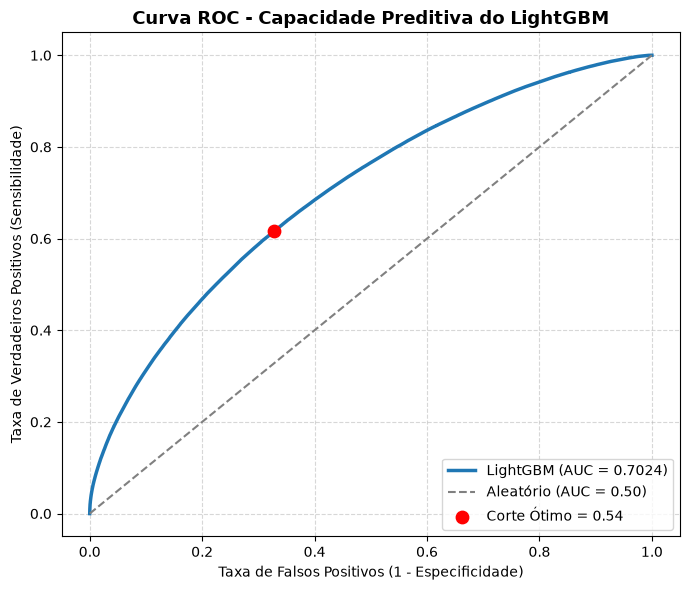

In [52]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, pred_probabilidades)
roc_auc = auc(fpr, tpr)

# Ponto ótimo pelo índice Youden (sensibilidade + especificidade máxima)
indice_otimo = np.argmax(tpr - fpr)
corte_otimo = thresholds[indice_otimo]

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'LightGBM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório (AUC = 0.50)')
plt.scatter(fpr[indice_otimo], tpr[indice_otimo], color='red', s=80, zorder=5, 
            label=f'Corte Ótimo = {corte_otimo:.2f}')

plt.title("Curva ROC - Capacidade Preditiva do LightGBM", fontsize=13, fontweight='bold')
plt.xlabel("Taxa de Falsos Positivos (1 - Especificidade)")
plt.ylabel("Taxa de Verdadeiros Positivos (Sensibilidade)")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# Cálculo ou Coleta Dinâmica dos Scores AUC-ROC 
# Se os modelos estiverem na memória, calculamos diretamente com X_test e y_test:
scores = {}

# Baseline: Classe Majoritária (por definição matemática, AUC = 0.50)
scores["Classe Majoritária (Baseline)"] = 0.5000

# Random Forest
if 'y_proba_rf' in locals():
    scores["Random Forest"] = roc_auc_score(y_test, y_proba_rf)
elif 'modelo_rf' in locals():
    scores["Random Forest"] = roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:, 1])

# XGBoost
if 'y_proba_xgb' in locals():
    scores["XGBoost"] = roc_auc_score(y_test, y_proba_xgb)
elif 'modelo_xgb' in locals():
    scores["XGBoost"] = roc_auc_score(y_test, modelo_xgb.predict_proba(X_test)[:, 1])

# LightGBM (Campeão)
if 'y_proba_prof' in locals():
    scores["LightGBM (Campeão)"] = roc_auc_score(y_test, y_proba_prof)
elif 'y_proba_lgbm' in locals():
    scores["LightGBM (Campeão)"] = roc_auc_score(y_test, y_proba_lgbm)
elif 'lgbm' in locals():
    scores["LightGBM (Campeão)"] = roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1])
elif 'modelo_lgbm_profundo' in locals():
    scores["LightGBM (Campeão)"] = roc_auc_score(y_test, modelo_lgbm_profundo.predict_proba(X_test)[:, 1])

# Converte para DataFrame e ordena do menor para o maior (para barra horizontal)
df_comp = pd.DataFrame(list(scores.items()), columns=["Modelo", "AUC_ROC"]).sort_values("AUC_ROC", ascending=True)

# Gráfico Executivo de Barras Horizontais 
plt.figure(figsize=(10, 5), dpi=150)

# Paleta de Cores com destaque no Campeão
cores = []
for m in df_comp["Modelo"]:
    if "LightGBM" in m:
        cores.append("#2ca02c")  # Verde para o Campeão
    elif "Baseline" in m or "Majoritária" in m:
        cores.append("#8c8c8c")  # Cinza neutro para o baseline
    else:
        cores.append("#1f77b4")  # Azul executivo para os demais

barras = plt.barh(df_comp["Modelo"], df_comp["AUC_ROC"], color=cores, height=0.55, alpha=0.88, edgecolor="black", lw=0.6)

# Linha de referência da adivinhação aleatória / baseline puro (0.50)
plt.axvline(0.50, color="gray", linestyle="--", lw=1.5, label="Aleatório / Baseline (0.50)")

# Rótulos de texto com o score exato ao lado de cada barra
for b in barras:
    w = b.get_width()
    is_campeao = w == df_comp["AUC_ROC"].max()
    texto = f"{w:.4f} ({w*100:.1f}%)" + (" 🏆" if is_campeao else "")
    cor_texto = "#1b5e20" if is_campeao else "#2c3e50"
    
    plt.text(
        w + 0.012, b.get_y() + b.get_height() / 2, texto,
        va='center', ha='left', fontsize=10, fontweight='bold', color=cor_texto
    )

plt.title("Comparativo de Desempenho dos Modelos — Métrica AUC-ROC", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("AUC-ROC Score (Área sob a Curva ROC)", fontsize=11, fontweight="bold")
plt.xlim(0.40, df_comp["AUC_ROC"].max() + 0.12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend(loc="lower right", frameon=True, fontsize=10)
plt.tight_layout()

# Salva em alta definição para o PowerPoint
plt.savefig("comparativo_roc_modelos_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()

print("Tabela Comparativa:")
display(df_comp.sort_values("AUC_ROC", ascending=False).reset_index(drop=True))


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Localização e Preparação dos Dados Municipais 
# Usamos resultado_metas_muni ou df_municipios (onde os nomes oficiais estão presentes)
if 'resultado_metas_muni' in locals() and 'NO_MUNICIPIO' in resultado_metas_muni.columns:
    df_fonte = resultado_metas_muni.copy()
    col_taxa = 'PC_ALUNO_ALFABETIZADO_2023' if 'PC_ALUNO_ALFABETIZADO_2023' in df_fonte.columns else 'PC_ALUNO_ALFABETIZADO'
elif 'df_municipios' in locals() and 'NO_MUNICIPIO' in df_municipios.columns:
    df_fonte = df_municipios[df_municipios.get('ID_TIPO_REDE', 5) == 5].copy()
    col_taxa = 'PC_ALUNO_ALFABETIZADO'
else:
    # Fallback caso os nomes estejam em df_municipios e as taxas em resultado_metas_muni
    df_fonte = resultado_metas_muni.copy()
    col_taxa = 'PC_ALUNO_ALFABETIZADO'

# Garante que a taxa seja numérica e remove nulos
df_fonte[col_taxa] = pd.to_numeric(df_fonte[col_taxa], errors='coerce')
df_muni_clean = df_fonte.dropna(subset=[col_taxa, 'NO_MUNICIPIO']).copy()

# Cria o rótulo legível: "Nome do Município - UF"
if 'SG_UF' in df_muni_clean.columns:
    df_muni_clean["LABEL"] = df_muni_clean["NO_MUNICIPIO"].str.title() + " - " + df_muni_clean["SG_UF"]
else:
    df_muni_clean["LABEL"] = df_muni_clean["NO_MUNICIPIO"].str.title()

# Agrupa por município (para evitar duplicatas de rede) pegando a média da taxa
df_ranking = df_muni_clean.groupby("LABEL", as_index=False)[col_taxa].mean()

# Seleção dos Top 10 e Bottom 10 
top10 = df_ranking.sort_values(by=col_taxa, ascending=True).tail(10)
bottom10 = df_ranking.sort_values(by=col_taxa, ascending=True).head(10)

#  Gráfico Executivo 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), dpi=150)
fig.suptitle("Disparidade Municipal: 10 Maiores vs 10 Menores Taxas de Alfabetização", 
             fontsize=15, fontweight="bold", y=0.98, color="#1a1a1a")

# Painel 1: Top 10 Melhores (Verde)
barras_top = ax1.barh(top10["LABEL"], top10[col_taxa], color="#2ca02c", height=0.6, alpha=0.88, edgecolor="black", lw=0.6)
ax1.axvline(80, color="darkgreen", linestyle="--", lw=1.5, label="Meta MEC 2030 (80%)")
ax1.set_xlim(0, 115)
ax1.set_title("🏆 Top 10 Municípios com Maior Alfabetização", fontsize=12, fontweight="bold", color="#1b5e20", pad=10)
ax1.set_xlabel("% Alunos Alfabetizados", fontsize=10, fontweight="bold")
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax1.legend(loc="lower right", fontsize=9)

for b in barras_top:
    w = b.get_width()
    ax1.text(w + 1.2, b.get_y() + b.get_height()/2, f"{w:.1f}%", 
             va='center', ha='left', fontsize=9, fontweight='bold', color="#1b5e20")

# Painel 2: Top 10 Piores (Vermelho)
barras_bot = ax2.barh(bottom10["LABEL"], bottom10[col_taxa], color="#d62728", height=0.6, alpha=0.88, edgecolor="black", lw=0.6)
ax2.axvline(80, color="darkgreen", linestyle="--", lw=1.5, label="Meta MEC 2030 (80%)")
ax2.set_xlim(0, 115)
ax2.set_title("⚠️ 10 Municípios com Menor Alfabetização (Atenção Urgente)", fontsize=12, fontweight="bold", color="#b71c1c", pad=10)
ax2.set_xlabel("% Alunos Alfabetizados", fontsize=10, fontweight="bold")
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax2.legend(loc="lower right", fontsize=9)

for b in barras_bot:
    w = b.get_width()
    ax2.text(w + 1.2, b.get_y() + b.get_height()/2, f"{w:.1f}%", 
             va='center', ha='left', fontsize=9, fontweight='bold', color="#b71c1c")

plt.tight_layout()

# Salva a imagem em alta definição para o slide
plt.savefig("top_bottom_10_municipios_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo com sucesso como 'top_bottom_10_municipios_powerpoint.png'!")


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for corte in [0.40, 0.50, 0.60]:
    pred_custom = (pred_probabilidades >= corte).astype(int)
    print("=" * 60)
    print(f" Ponto de Corte = {corte:.2f} ({corte*100:.0f}%)")
    print(f"Alunos previstos como alfabetizados: {pred_custom.sum():,} ({pred_custom.mean()*100:.1f}%)")
    print("=" * 60)
    print(classification_report(y_test, pred_custom, digits=4))


 Ponto de Corte = 0.40 (40%)
Alunos previstos como alfabetizados: 965,089 (79.2%)
              precision    recall  f1-score   support

           0     0.7012    0.3164    0.4361    560587
           1     0.6029    0.8851    0.7172    657446

    accuracy                         0.6233   1218033
   macro avg     0.6521    0.6007    0.5766   1218033
weighted avg     0.6482    0.6233    0.5878   1218033

 Ponto de Corte = 0.50 (50%)
Alunos previstos como alfabetizados: 708,051 (58.1%)
              precision    recall  f1-score   support

           0     0.6265    0.5699    0.5969    560587
           1     0.6595    0.7103    0.6839    657446

    accuracy                         0.6457   1218033
   macro avg     0.6430    0.6401    0.6404   1218033
weighted avg     0.6443    0.6457    0.6439   1218033

 Ponto de Corte = 0.60 (60%)
Alunos previstos como alfabetizados: 428,429 (35.2%)
              precision    recall  f1-score   support

           0     0.5637    0.7941    0.6594  